,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1000,3.5000,1.4000,0.2000,0,setosa
1,4.9000,3.0000,1.4000,0.2000,0,setosa
2,4.7000,3.2000,1.3000,0.2000,0,setosa
147,6.5000,3.0000,5.2000,2.0000,2,virginica
148,6.2000,3.4000,5.4000,2.3000,2,virginica
149,5.9000,3.0000,5.1000,1.8000,2,virginica


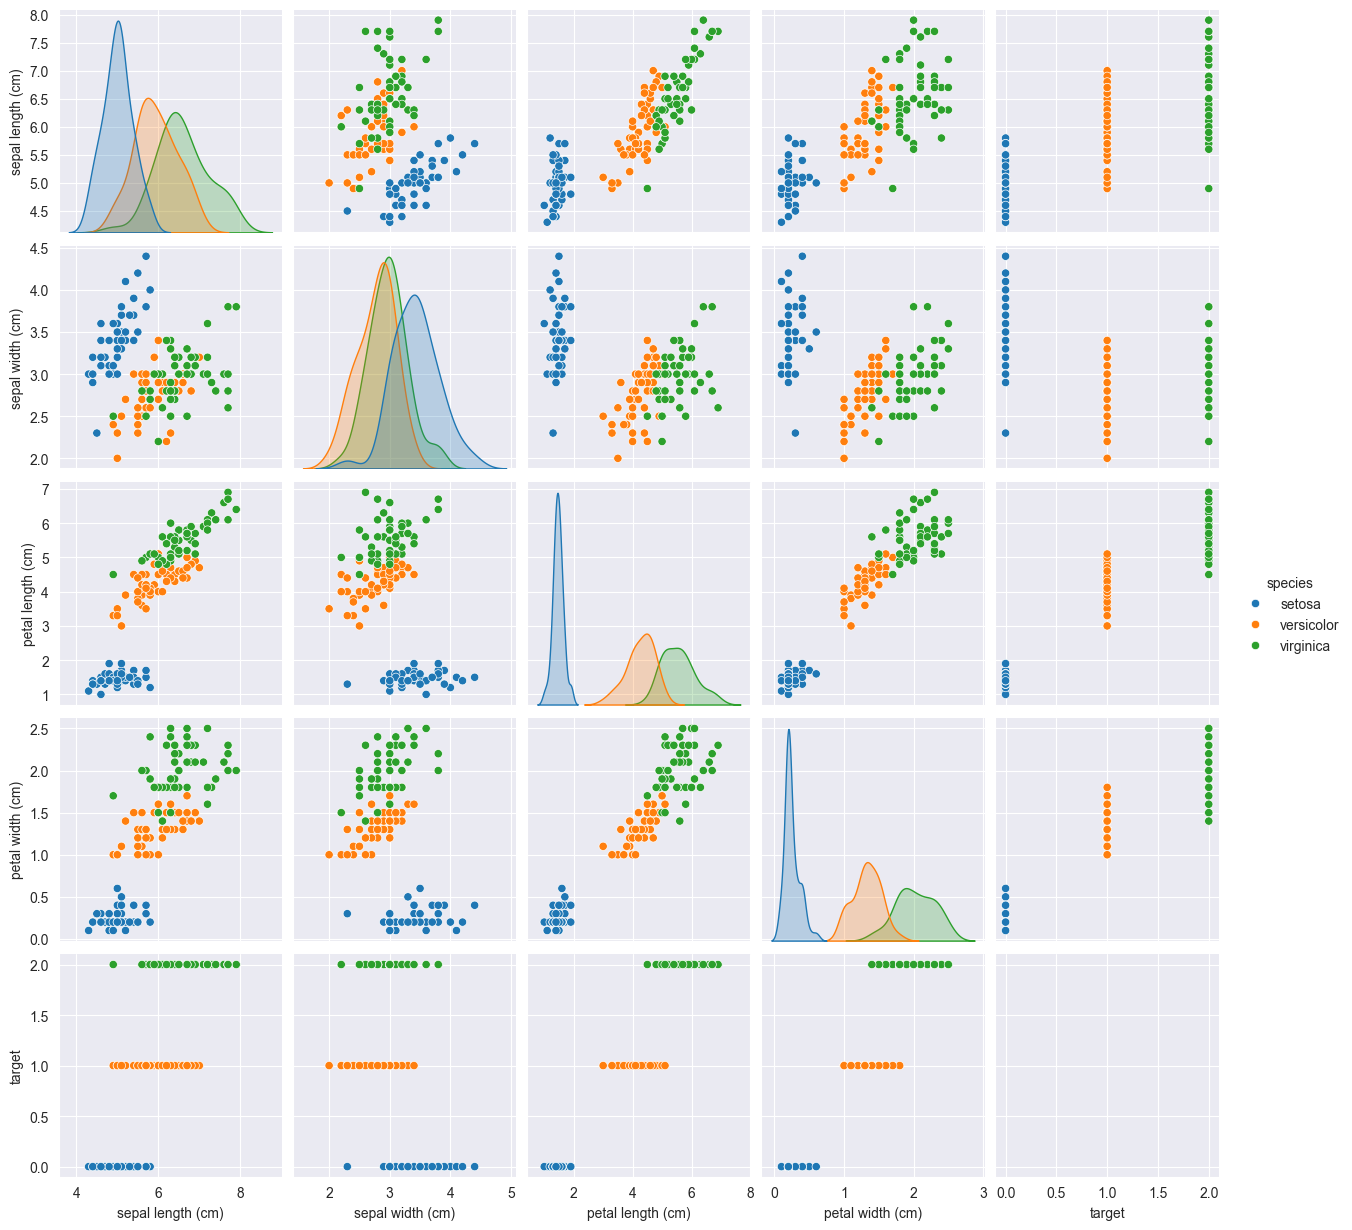

In [5]:
# setup
import os
from mlwpy import *
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn import datasets
from sklearn import (datasets, metrics, model_selection as skms, naive_bayes, neighbors)
import pandas as pd
import seaborn as sns
import memory_profiler, sys
from mlwpy import *
from sklearn import datasets, neighbors, model_selection as skms

# Load Iris dataset
iris = datasets.load_iris()

# Create a DataFrame
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_df['target'] = iris.target
iris_df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

# Display first and last 3 rows
display(pd.concat([iris_df.head(3), iris_df.tail(3)]))

# Visualize with seaborn
sns.pairplot(iris_df, hue='species')
plt.show()

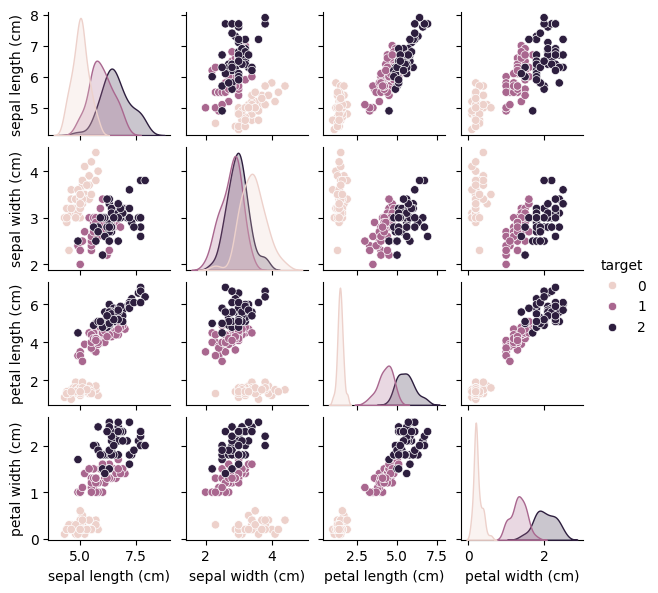

In [3]:
sns.pairplot(iris_df, hue= 'target', height=1.5);

In [4]:
print('targets: {}'.format(iris.target_names), iris.target_names[0], sep="\n")

targets: ['setosa' 'versicolor' 'virginica']
setosa


In [5]:
(iris_train_ftrs, iris_test_ftrs, iris_train_tgt, iris_test_tgt) = skms.train_test_split(iris.data, iris.target, test_size=0.25)

print("Train features shape:", iris_train_ftrs.shape)
print("Test features shape:", iris_test_ftrs.shape)

Train features shape: (112, 4)
Test features shape: (38, 4)


In [8]:
answer_key = np.array([True, True, False, True])
student_answers = np.array([True, True, True, True])
correct = answer_key == student_answers
num_correct = correct.sum() # True == 1, add them up
print("manual accuracy:", num_correct / len(answer_key))
print("sklearn accuracy:", metrics.accuracy_score(answer_key, student_answers))

manual accuracy: 0.75
sklearn accuracy: 0.75


In [9]:
# default n_neighbors = 5
knn = neighbors.KNeighborsClassifier(n_neighbors=3)
fit = knn.fit(iris_train_ftrs, iris_train_tgt)
preds = fit.predict(iris_test_ftrs)
# evaluate our predictions against the held-back testing targets
print("3NN accuracy:",
metrics.accuracy_score(iris_test_tgt, preds))

3NN accuracy: 1.0


In [10]:
nb = naive_bayes.GaussianNB()
fit = nb.fit(iris_train_ftrs, iris_train_tgt)
preds = fit.predict(iris_test_ftrs)
print("NB accuracy:",
metrics.accuracy_score(iris_test_tgt, preds))

NB accuracy: 1.0


In [14]:
# we set random_state so the results are reproducible
# otherwise, we get different training and testing sets
# more details in Chapter 5
iris = datasets.load_iris()

# split the data
(iris_train_ftrs, iris_test_ftrs,
 iris_train_tgt, iris_test_tgt) = skms.train_test_split(
     iris.data, iris.target,
     test_size=0.90,
     random_state=42
 )

# define models to compare
models = {
    'kNN': neighbors.KNeighborsClassifier(n_neighbors=3),
    'NB': naive_bayes.GaussianNB()
}

# train and evaluate each model
for name, model in models.items():
    fit = model.fit(iris_train_ftrs, iris_train_tgt)
    predictions = fit.predict(iris_test_ftrs)

    score = metrics.accuracy_score(iris_test_tgt, predictions)
    print("{:>3s}: {:.2f}".format(name, score))

kNN: 0.96
 NB: 0.81


In [15]:
%%timeit -r1 -n1
# Split the iris dataset into training and testing sets
(iris_train_ftrs, iris_test_ftrs,
 iris_train_tgt, iris_test_tgt) = skms.train_test_split(
     iris.data, iris.target,
     test_size=0.25
 )


501 μs ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


In [16]:
%%timeit -r1
nb = naive_bayes.GaussianNB()
fit = nb.fit(iris_train_ftrs, iris_train_tgt)
preds = fit.predict(iris_test_ftrs)
metrics.accuracy_score(iris_test_tgt, preds)

755 μs ± 0 ns per loop (mean ± std. dev. of 1 run, 1,000 loops each)


In [17]:
%%timeit -r1
knn = neighbors.KNeighborsClassifier(n_neighbors=3)
fit = knn.fit(iris_train_ftrs, iris_train_tgt)
preds = fit.predict(iris_test_ftrs)
metrics.accuracy_score(iris_test_tgt, preds)

4.33 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 100 loops each)


In [18]:
# fitting
nb = naive_bayes.GaussianNB()
%timeit -r1 fit = nb.fit(iris_train_ftrs, iris_train_tgt)
knn = neighbors.KNeighborsClassifier(n_neighbors=3)
%timeit -r1 fit = knn.fit(iris_train_ftrs, iris_train_tgt)

396 μs ± 0 ns per loop (mean ± std. dev. of 1 run, 1,000 loops each)
355 μs ± 0 ns per loop (mean ± std. dev. of 1 run, 1,000 loops each)


In [20]:
 # predicting
nb = naive_bayes.GaussianNB()
fit = nb.fit(iris_train_ftrs, iris_train_tgt)
%timeit -r1 preds = fit.predict(iris_test_ftrs)
knn = neighbors.KNeighborsClassifier(n_neighbors=3)
fit = knn.fit(iris_train_ftrs, iris_train_tgt)
%timeit -r1 preds = fit.predict(iris_test_ftrs)

122 μs ± 0 ns per loop (mean ± std. dev. of 1 run, 10,000 loops each)
3.58 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 100 loops each)


In [10]:
%load_ext memory_profiler

The memory_profiler extension is already loaded. To reload it, use:
  %reload_ext memory_profiler


In [21]:
%%memit -r10
nb = naive_bayes.GaussianNB()
fit = nb.fit(iris_train_ftrs, iris_train_tgt)
preds = fit.predict(iris_test_ftrs)

peak memory: 178.97 MiB, increment: 0.00 MiB


In [24]:
%%memit
knn = neighbors.KNeighborsClassifier(n_neighbors=3)
fit = knn.fit(iris_train_ftrs, iris_train_tgt)
preds = fit.predict(iris_test_ftrs)

peak memory: 180.46 MiB, increment: 0.00 MiB


In [31]:
os.listdir()

['.idea',
 'CSC525_Week1_CT_NLP_Transformers_John_Wensink.docx',
 'CSC525_Week1_CT_NLP_Transformers_John_Wensink.pdf',
 'HuggingFace_Week1_DistilBERT_AmazonReview.py',
 'HuggingFace_Week1_DistilBERT_Test.py',
 'HuggingFace_Week1_Setup.py',
 'Machine Learning with Python for Everyone.pdf',
 'mlwpy.py',
 'mlwpy_jupyter.ipynb',
 'Textbook_Chapter2.py',
 'Textbook_Chapter3.ipynb',
 'Textbook_Chapter3.py',
 '__pycache__']

In [3]:
%load_ext memory_profiler

from sklearn import datasets, neighbors, model_selection as skms

def knn_memtest(train, train_tgt, test):
    knn = neighbors.KNeighborsClassifier(n_neighbors=3)
    fit = knn.fit(train, train_tgt)
    preds = fit.predict(test)

iris = datasets.load_iris()
tts = skms.train_test_split(iris.data, iris.target, test_size=0.25)
iris_train_ftrs, iris_test_ftrs, iris_train_tgt, iris_test_tgt = tts

%memit knn_memtest(iris_train_ftrs, iris_train_tgt, iris_test_ftrs)

The memory_profiler extension is already loaded. To reload it, use:
  %reload_ext memory_profiler
peak memory: 208.01 MiB, increment: 0.00 MiB


In [4]:
# Run this once at the top of your notebook
%load_ext memory_profiler

from sklearn import naive_bayes, model_selection as skms, datasets

def nb_go(train_ftrs, test_ftrs, train_tgt):
    nb = naive_bayes.GaussianNB()
    fit = nb.fit(train_ftrs, train_tgt)
    preds = fit.predict(test_ftrs)

def split_data(dataset):
    split = skms.train_test_split(dataset.data, dataset.target, test_size=0.25)
    return split[:-1]  # drop test target

# Prepare the data
iris = datasets.load_iris()
train_ftrs, test_ftrs, train_tgt = split_data(iris)

# Profile memory usage of nb_go
%memit nb_go(train_ftrs, test_ftrs, train_tgt)


The memory_profiler extension is already loaded. To reload it, use:
  %reload_ext memory_profiler
peak memory: 207.97 MiB, increment: 0.01 MiB


In [8]:
import timeit
import functools as ft
import memory_profiler
from mlwpy import *
from sklearn import neighbors, naive_bayes, model_selection as skms, datasets

def knn_go(train_ftrs, test_ftrs, train_tgt):
    knn = neighbors.KNeighborsClassifier(n_neighbors=3)
    fit = knn.fit(train_ftrs, train_tgt)
    preds = fit.predict(test_ftrs)

def nb_go(train_ftrs, test_ftrs, train_tgt):
    nb = naive_bayes.GaussianNB()
    fit = nb.fit(train_ftrs, train_tgt)
    preds = fit.predict(test_ftrs)

def split_data(dataset):
    split = skms.train_test_split(dataset.data, dataset.target, test_size=0.25)
    return split[:-1]  # drop test target

def msr_time(go, args):
    call = ft.partial(go, *args)
    tu = min(timeit.Timer(call).repeat(repeat=3, number=100))
    print("{:<6}: ~{:.4f} sec".format(go.__name__, tu))

def msr_mem(go, args):
    base = memory_profiler.memory_usage()[0]
    mu = memory_profiler.memory_usage((go, args), max_usage=True)
    print("{:<6}: ~{:.4f} MiB".format(go.__name__, mu - base))

# --- Manual input for Jupyter ---
which_msr = 'mem'  # 'time' or 'mem'
which_go = 'knn'   # 'knn' or 'nb'
# --------------------------------

msr = {'time': msr_time, 'mem': msr_mem}[which_msr]
go = {'nb': nb_go, 'knn': knn_go}[which_go]
sd = split_data(datasets.load_iris())
msr(go, sd)


knn_go: ~0.0000 MiB
